#### 1) Data Understanding

* 1) Understand Columns
* 2) check datatypes
* 3) describe numerical columns
* 4) describe categorical columns

In [371]:
#1) Understand Columns
import pandas as pd 
import numpy as np
import re
df = pd.read_csv('property_data_08152025_v2.csv')
df

,url,logo_url,developer_url,developer_name,property_title,property_type,location,status,reference_no,bedrooms,...,phone_placeholder,country_flag_url,message_box_placeholder,price,image_urls,payment_plan_raw,payment_plan,amenities,delivery_in,property_size
0,https://www.nawy.com/compound/1572-fcc/propert...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/125,Al - Borouj Misr Developments Group (ABM),Office for sale in FCC in Golden Square by Al ...,Office,"FCC, Golden Square, Egypt",NaN,83320.0,NaN,...,NaN,NaN,NaN,NaN,['https://prod-images.cooingestate.com/process...,NaN,NaN,NaN,2028,NaN
1,https://www.nawy.com/compound/38-hyde-park/pro...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/15,Hyde Park,Villa 4 bedrooms for resale in Hyde Park in Ne...,Villa,"Hyde Park, New Cairo, Egypt",NaN,7004.0,4.0,...,NaN,NaN,NaN,NaN,['https://prod-images.cooingestate.com/process...,NaN,NaN,"Livability, Medical center, Commercial strip, ...",NaN,NaN
2,https://www.nawy.com/compound/728-lasirena-pal...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/215,Lasirena Group,Apartment for sale in Lasirena Palm Beach with...,Apartment,"Lasirena Palm Beach, Ain Sokhna, Egypt",NaN,31976.0,2.0,...,NaN,NaN,NaN,NaN,['https://prod-images.cooingestate.com/process...,NaN,NaN,"Infrastructure, Livability, Commercial strip, ...",2026,NaN
3,https://www.nawy.com/compound/1219-nurai/prope...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/168,Mercon Developments,Retail for sale in Nurai - Nurai Walk - in New...,Retail,"Nurai, El Lotus, Egypt",NaN,63905.0,NaN,...,NaN,NaN,NaN,NaN,['https://prod-images.cooingestate.com/process...,NaN,NaN,NaN,2027,NaN
4,https://www.nawy.com/compound/260-v-residences...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/8,SODIC,Penthouse 4 bedrooms for resale in V Residence...,Penthouse,"V Residences By Villette, Golden Square, Egypt",NaN,75110.0,4.0,...,NaN,NaN,NaN,"30,000,000EGP",['https://prod-images.cooingestate.com/process...,NaN,NaN,Has roof,Delivered,198m²
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90138,https://www.nawy.com/compound/10-mountain-view...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/6,Mountain View,Townhouse for sale in Mountain View October Pa...,Townhouse,"Mountain View October Park, 6th of October Cit...",NaN,34660.0,4.0,...,NaN,NaN,NaN,NaN,['https://prod-images.cooingestate.com/process...,NaN,NaN,"Has roof, Livability, Infrastructure, Clubhouse",Delivered,NaN
90139,https://www.nawy.com/compound/544-serrano/prop...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/136,New Plan,Serrano - Apartment - 1 bedroom -ground floor,Apartment,"Serrano, New Capital City, Egypt",NaN,6523.0,1.0,...,NaN,NaN,NaN,NaN,['https://prod-images.cooingestate.com/process...,NaN,NaN,"Commercial strip, Business Hub, bicycles lanes...",Delivered,NaN
90140,https://www.nawy.com/compound/927-salt/propert...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/33,Tatweer Misr,Chalet for sale in Salt with 3 bedrooms in Nor...,Chalet,"Salt, Ras El Hekma, Egypt",NaN,35724.0,3.0,...,NaN,NaN,NaN,NaN,['https://prod-images.cooingestate.com/process...,NaN,NaN,"Garden, Clubhouse, Commercial strip",2027,NaN
90141,https://www.nawy.com/compound/165-jefaira/prop...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/13,Inertia Egypt,Chalet for sale in Jefaira with 4 bedrooms in ...,Chalet,"Jefaira, Ras El Hekma, Egypt",NaN,32647.0,4.0,...,NaN,NaN,NaN,NaN,['https://prod-images.cooingestate.com/process...,NaN,NaN,"Has roof, Terrace, Clubhouse, Schools, Medical...",2026,NaN


In [372]:
#2) check datatypes
df.dtypes
#reference_no -> object
#price -> float64
#property_size -> float64

url                         object
logo_url                    object
developer_url               object
developer_name              object
property_title              object
property_type               object
location                    object
status                     float64
reference_no               float64
bedrooms                   float64
bathrooms                  float64
compound                    object
sale_type                   object
finishing                   object
description                 object
phone_placeholder          float64
country_flag_url           float64
message_box_placeholder    float64
price                       object
image_urls                  object
payment_plan_raw           float64
payment_plan               float64
amenities                   object
delivery_in                 object
property_size               object
dtype: object

In [373]:
#reference_no -> object
df['reference_no'].unique()

array([83320.,  7004., 31976., ..., 35724., 32647., 12837.],
      shape=(89679,))

In [374]:
df['reference_no'] = (
    df['reference_no']
    .dropna()                   # avoid NaN casting error
    .astype(int)                # remove .0
    .astype(str)                # convert to string
)

# # For NaN rows, fill them back as None/string if needed:
# df['reference_no'] = df['reference_no'].replace("nan", None)

In [375]:
df['reference_no'].astype(str)


0        83320
1         7004
2        31976
3        63905
4        75110
         ...  
90138    34660
90139     6523
90140    35724
90141    32647
90142    12837
Name: reference_no, Length: 90143, dtype: object

In [376]:
df['delivery_in'].unique()

array(['2028', nan, '2026', '2027', 'Delivered', '2029', '2025', '2030',
       '2034', '2033', '2041', '2053', '2052', '2032', '2060', '2073',
       '2068', '2057', '2064', '2070', '2038', '2066', '2045', '2050',
       '2076', '2031', '2047', '2049', '2061', '2035', '2039', '2063',
       '2059', '2067', '2051', '2037', '2069', '2058', '2065', '2056',
       '2071', '2062', '2048', '2036', '2042', '2043', '2054', '2040',
       '2077', '2046', '2044', '2075', '2072', '2055', '2074'],
      dtype=object)

In [377]:

# df['delivery_in'] = pd.to_numeric(df['delivery_in'], errors='coerce')
# df['delivery_in'] = df['delivery_in'].fillna(df['delivery_in'].median())
# df['delivery_in'] = df['delivery_in'].astype(int)
# df['delivery_in'].dtypes


In [378]:
df['delivery_in'].unique()

array(['2028', nan, '2026', '2027', 'Delivered', '2029', '2025', '2030',
       '2034', '2033', '2041', '2053', '2052', '2032', '2060', '2073',
       '2068', '2057', '2064', '2070', '2038', '2066', '2045', '2050',
       '2076', '2031', '2047', '2049', '2061', '2035', '2039', '2063',
       '2059', '2067', '2051', '2037', '2069', '2058', '2065', '2056',
       '2071', '2062', '2048', '2036', '2042', '2043', '2054', '2040',
       '2077', '2046', '2044', '2075', '2072', '2055', '2074'],
      dtype=object)

In [379]:
#price -> float64
df['price'].unique()

array([nan, '30,000,000EGP', '25,069,000EGP', ..., '10,989,825EGP',
       '11,066,250EGP', '31,131,216EGPMax Price:31,713,108EGP'],
      shape=(11890,), dtype=object)

In [380]:
import pandas as pd
import numpy as np

# Assuming your data is in a DataFrame called df with a column named 'price'

# Function to clean and convert price values
def clean_price(price_str):
    if pd.isna(price_str):
        return np.nan
    
    # Convert to string if not already
    price_str = str(price_str)
    
    # Handle cases with multiple prices (take average)
    if 'Max Price:' in price_str or ':' in price_str:
        # Extract all numbers from the string
        numbers = []
        parts = price_str.replace('Max Price:', '').split('EGP')
        for part in parts:
            cleaned = part.replace(',', '').strip()
            if cleaned and cleaned.replace('.', '').isdigit():
                numbers.append(float(cleaned))
        if numbers:
            return int(np.mean(numbers))
    
    # Standard case: single price
    cleaned = price_str.replace('EGP', '').replace(',', '').strip()
    if cleaned and cleaned.replace('.', '').isdigit():
        return int(float(cleaned))
    
    return np.nan

# Apply the cleaning function
df['price'] = df['price'].apply(clean_price)



In [381]:
df['price'].unique()

array([      nan, 30000000., 25069000., ..., 10989825., 11066250.,
       31422162.], shape=(11540,))

In [382]:
df['price'].dtype

dtype('float64')

In [383]:
#property_size -> float64

def format_property_size(arg):
    if pd.isna(arg):
        return None
    
    # Extract numbers
    numbers = re.findall(r'\d+', str(arg))
    numbers = [float(num) for num in numbers]
    
    if not numbers:
        return None
    
    # If range (e.g., 120–150) → average, else single value
    return sum(numbers) / len(numbers)

df['property_size'] = df['property_size'].apply(format_property_size)
df['property_size']

0          NaN
1          NaN
2          NaN
3          NaN
4        198.0
         ...  
90138      NaN
90139      NaN
90140      NaN
90141      NaN
90142      NaN
Name: property_size, Length: 90143, dtype: float64

In [384]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90143 entries, 0 to 90142
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   url                      90143 non-null  object 
 1   logo_url                 90143 non-null  object 
 2   developer_url            90143 non-null  object 
 3   developer_name           90031 non-null  object 
 4   property_title           90143 non-null  object 
 5   property_type            89952 non-null  object 
 6   location                 89952 non-null  object 
 7   status                   0 non-null      float64
 8   reference_no             89952 non-null  object 
 9   bedrooms                 76072 non-null  float64
 10  bathrooms                72748 non-null  float64
 11  compound                 89952 non-null  object 
 12  sale_type                89952 non-null  object 
 13  finishing                88668 non-null  object 
 14  description           

In [385]:
# * 3) describe numerical columns
df.describe()

,status,bedrooms,bathrooms,phone_placeholder,country_flag_url,message_box_placeholder,price,payment_plan_raw,payment_plan,property_size
count,0.0,76072.000000,72748.000000,0.0,0.0,0.0,1.861300e+04,0.0,0.0,18596.000000
mean,NaN,2.846724,2.959215,NaN,NaN,NaN,1.848427e+07,NaN,NaN,181.401027
std,NaN,1.002834,1.209165,NaN,NaN,NaN,2.023274e+07,NaN,NaN,125.317037
min,NaN,1.000000,-4.000000,NaN,NaN,NaN,8.500000e+05,NaN,NaN,12.000000
25%,NaN,2.000000,2.000000,NaN,NaN,NaN,8.500000e+06,NaN,NaN,118.000000
50%,NaN,3.000000,3.000000,NaN,NaN,NaN,1.338805e+07,NaN,NaN,160.000000
75%,NaN,3.000000,3.000000,NaN,NaN,NaN,2.126100e+07,NaN,NaN,215.000000
max,NaN,45.000000,45.000000,NaN,NaN,NaN,7.600000e+08,NaN,NaN,7382.000000


In [386]:
df[df['bathrooms'] == -4]

,url,logo_url,developer_url,developer_name,property_title,property_type,location,status,reference_no,bedrooms,...,phone_placeholder,country_flag_url,message_box_placeholder,price,image_urls,payment_plan_raw,payment_plan,amenities,delivery_in,property_size
9368,https://www.nawy.com/compound/5-marassi/proper...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/4,Emaar Misr,The Greek Village - Apartment,Apartment,"Marassi, Sidi Abdel Rahman, Egypt",NaN,2123,3.0,...,NaN,NaN,NaN,NaN,['https://prod-images.cooingestate.com/process...,NaN,NaN,"Infrastructure, Livability, Clubhouse, Commerc...",Delivered,NaN


In [387]:
drop_index = df[df['bathrooms'] == -4].index
df.drop(drop_index, axis=0, inplace=True)

In [388]:
# * 3) describe numerical columns
df.describe()

,status,bedrooms,bathrooms,phone_placeholder,country_flag_url,message_box_placeholder,price,payment_plan_raw,payment_plan,property_size
count,0.0,76071.000000,72747.000000,0.0,0.0,0.0,1.861300e+04,0.0,0.0,18596.000000
mean,NaN,2.846722,2.959311,NaN,NaN,NaN,1.848427e+07,NaN,NaN,181.401027
std,NaN,1.002841,1.208898,NaN,NaN,NaN,2.023274e+07,NaN,NaN,125.317037
min,NaN,1.000000,-3.000000,NaN,NaN,NaN,8.500000e+05,NaN,NaN,12.000000
25%,NaN,2.000000,2.000000,NaN,NaN,NaN,8.500000e+06,NaN,NaN,118.000000
50%,NaN,3.000000,3.000000,NaN,NaN,NaN,1.338805e+07,NaN,NaN,160.000000
75%,NaN,3.000000,3.000000,NaN,NaN,NaN,2.126100e+07,NaN,NaN,215.000000
max,NaN,45.000000,45.000000,NaN,NaN,NaN,7.600000e+08,NaN,NaN,7382.000000


In [389]:
df[df['bathrooms'] == -3]

,url,logo_url,developer_url,developer_name,property_title,property_type,location,status,reference_no,bedrooms,...,phone_placeholder,country_flag_url,message_box_placeholder,price,image_urls,payment_plan_raw,payment_plan,amenities,delivery_in,property_size
78239,https://www.nawy.com/compound/222-district-5/p...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/65,Marakez,Plateau - Apartment Typical,Apartment,"DISTRICT 5, South New Cairo, Egypt",NaN,4210,1.0,...,NaN,NaN,NaN,NaN,['https://prod-images.cooingestate.com/process...,NaN,NaN,"Clubhouse, Medical center, Business Hub",2025,NaN


In [390]:
drop_index = df[df['bathrooms'] == -3].index
df.drop(drop_index, axis=0, inplace=True)

In [391]:
#soldout 
df[df['bathrooms'] == 45]


,url,logo_url,developer_url,developer_name,property_title,property_type,location,status,reference_no,bedrooms,...,phone_placeholder,country_flag_url,message_box_placeholder,price,image_urls,payment_plan_raw,payment_plan,amenities,delivery_in,property_size
57766,https://www.nawy.com/compound/6-mivida/propert...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/4,Emaar Misr,Apartment 45 bedrooms for resale in Mivida in ...,Apartment,"Mivida, New Cairo, Egypt",NaN,3872,45.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Clubhouse, Livability, Infrastructure, Schools...",NaN,NaN


In [392]:
drop_index = df[df['bathrooms'] == 45].index
df.drop(drop_index, axis=0, inplace=True)

In [393]:
drop_index = df[df['property_size'] == 7382].index
df.drop(drop_index, axis=0, inplace=True)

In [394]:
drop_index = df[df['property_size'] == 2600].index
df.drop(drop_index, axis=0, inplace=True)

In [395]:
df.describe()

,status,bedrooms,bathrooms,phone_placeholder,country_flag_url,message_box_placeholder,price,payment_plan_raw,payment_plan,property_size
count,0.0,76068.000000,72744.000000,0.0,0.0,0.0,1.861100e+04,0.0,0.0,18594.000000
mean,NaN,2.846164,2.958773,NaN,NaN,NaN,1.848124e+07,NaN,NaN,180.883699
std,NaN,0.991092,1.198575,NaN,NaN,NaN,2.023124e+07,NaN,NaN,112.261112
min,NaN,1.000000,1.000000,NaN,NaN,NaN,8.500000e+05,NaN,NaN,12.000000
25%,NaN,2.000000,2.000000,NaN,NaN,NaN,8.500000e+06,NaN,NaN,118.000000
50%,NaN,3.000000,3.000000,NaN,NaN,NaN,1.338156e+07,NaN,NaN,160.000000
75%,NaN,3.000000,3.000000,NaN,NaN,NaN,2.125476e+07,NaN,NaN,215.000000
max,NaN,33.000000,23.000000,NaN,NaN,NaN,7.600000e+08,NaN,NaN,2000.000000


In [396]:
# * 4) describe categorical columns
df.describe(include="O")

,url,logo_url,developer_url,developer_name,property_title,property_type,location,reference_no,compound,sale_type,finishing,description,image_urls,amenities,delivery_in
count,90138,90138,90138,90026,90138,89947,89947,89947,89947,89947,88663,89717,86791,56697,86915
unique,89865,363,295,295,17904,27,1281,89673,1281,3,5,47507,55491,882,54
top,https://www.nawy.com/compound/530-silversands/...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/16,Palm Hills Developments,Apartment for sale in Bloomfields with 3 bedr...,Apartment,"Mountain View ICity New Cairo, New Cairo, Egypt",22404,Mountain View ICity New Cairo,Developer Sale,Finished,A Retail in Taj Tower by Taj Misr Development...,['https://prod-images.cooingestate.com/process...,Garden,Delivered
freq,2,7186,7201,7195,431,38421,1757,2,1757,68881,42586,425,149,7485,33352


In [397]:
# desc
cat_cols = df.select_dtypes(include='O').columns
for col in cat_cols:
    print(f"col name \'{col}\' has nuniques = {df[col].nunique()}") 
    print(f"uniques:\n{df[col].unique()}")
    print()
    print("*" * 50)
    print()

col name 'url' has nuniques = 89865
uniques:
['https://www.nawy.com/compound/1572-fcc/property/83320-office-for-sale-in-fcc-in-golden-square-by-al-borouj-misr-developments-group-abm'
 'https://www.nawy.com/compound/38-hyde-park/property/7004-hyde-park-4-bedrooms-villa'
 'https://www.nawy.com/compound/728-lasirena-palm-beach/property/31976-apartment-for-sale-in-lasirena-palm-beach-with-2-bedrooms-in-ain-sokhna-by-lasirena-group'
 ...
 'https://www.nawy.com/compound/927-salt/property/35724-chalet-for-sale-in-salt-with-3-bedrooms-in-north-coast-by-tatweer-misr'
 'https://www.nawy.com/compound/165-jefaira/property/32647-chalet-for-sale-in-jefaira-with-4-bedrooms-in-north-coast-by-inertia-egypt'
 'https://www.nawy.com/compound/408-parklane/property/12837-parklane-office']

**************************************************

col name 'logo_url' has nuniques = 363
uniques:
['https://prod-images.cooingestate.com/processed/developer/logo_image/125/medium.webp'
 'https://prod-images.cooingestate

In [398]:
for col in cat_cols:
    print(f"col name \'{col}\' count of each unique is\n{df[col].value_counts()}")
    print()
    print("*" * 50)
    print()

col name 'url' count of each unique is
url
https://www.nawy.com/compound/530-silversands/property/57840-duplex-for-sale-in-silversands-with-3-bedrooms-in-sidi-heneish-by-ora-developers                                           2
https://www.nawy.com/compound/494-entrada/property/6074-entrada-apartment-garden                                                                                                        2
https://www.nawy.com/compound/4-uptown-cairo/property/64741-twinhouse-for-sale-at-uptown-cairo                                                                                          2
https://www.nawy.com/compound/1505-jirian-mountain-view/property/87633-nile-cascades-residences-for-sale-in-jirian-mountain-view-with-3-bedrooms-in-el-sheikh-zayed-by-mountain-view    2
https://www.nawy.com/compound/196-haptown/property/64624-apartment-for-sale-in-haptown                                                                                                  2
                           

In [399]:
df

,url,logo_url,developer_url,developer_name,property_title,property_type,location,status,reference_no,bedrooms,...,phone_placeholder,country_flag_url,message_box_placeholder,price,image_urls,payment_plan_raw,payment_plan,amenities,delivery_in,property_size
0,https://www.nawy.com/compound/1572-fcc/propert...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/125,Al - Borouj Misr Developments Group (ABM),Office for sale in FCC in Golden Square by Al ...,Office,"FCC, Golden Square, Egypt",NaN,83320,NaN,...,NaN,NaN,NaN,NaN,['https://prod-images.cooingestate.com/process...,NaN,NaN,NaN,2028,NaN
1,https://www.nawy.com/compound/38-hyde-park/pro...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/15,Hyde Park,Villa 4 bedrooms for resale in Hyde Park in Ne...,Villa,"Hyde Park, New Cairo, Egypt",NaN,7004,4.0,...,NaN,NaN,NaN,NaN,['https://prod-images.cooingestate.com/process...,NaN,NaN,"Livability, Medical center, Commercial strip, ...",NaN,NaN
2,https://www.nawy.com/compound/728-lasirena-pal...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/215,Lasirena Group,Apartment for sale in Lasirena Palm Beach with...,Apartment,"Lasirena Palm Beach, Ain Sokhna, Egypt",NaN,31976,2.0,...,NaN,NaN,NaN,NaN,['https://prod-images.cooingestate.com/process...,NaN,NaN,"Infrastructure, Livability, Commercial strip, ...",2026,NaN
3,https://www.nawy.com/compound/1219-nurai/prope...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/168,Mercon Developments,Retail for sale in Nurai - Nurai Walk - in New...,Retail,"Nurai, El Lotus, Egypt",NaN,63905,NaN,...,NaN,NaN,NaN,NaN,['https://prod-images.cooingestate.com/process...,NaN,NaN,NaN,2027,NaN
4,https://www.nawy.com/compound/260-v-residences...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/8,SODIC,Penthouse 4 bedrooms for resale in V Residence...,Penthouse,"V Residences By Villette, Golden Square, Egypt",NaN,75110,4.0,...,NaN,NaN,NaN,30000000.0,['https://prod-images.cooingestate.com/process...,NaN,NaN,Has roof,Delivered,198.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90138,https://www.nawy.com/compound/10-mountain-view...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/6,Mountain View,Townhouse for sale in Mountain View October Pa...,Townhouse,"Mountain View October Park, 6th of October Cit...",NaN,34660,4.0,...,NaN,NaN,NaN,NaN,['https://prod-images.cooingestate.com/process...,NaN,NaN,"Has roof, Livability, Infrastructure, Clubhouse",Delivered,NaN
90139,https://www.nawy.com/compound/544-serrano/prop...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/136,New Plan,Serrano - Apartment - 1 bedroom -ground floor,Apartment,"Serrano, New Capital City, Egypt",NaN,6523,1.0,...,NaN,NaN,NaN,NaN,['https://prod-images.cooingestate.com/process...,NaN,NaN,"Commercial strip, Business Hub, bicycles lanes...",Delivered,NaN
90140,https://www.nawy.com/compound/927-salt/propert...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/33,Tatweer Misr,Chalet for sale in Salt with 3 bedrooms in Nor...,Chalet,"Salt, Ras El Hekma, Egypt",NaN,35724,3.0,...,NaN,NaN,NaN,NaN,['https://prod-images.cooingestate.com/process...,NaN,NaN,"Garden, Clubhouse, Commercial strip",2027,NaN
90141,https://www.nawy.com/compound/165-jefaira/prop...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/13,Inertia Egypt,Chalet for sale in Jefaira with 4 bedrooms in ...,Chalet,"Jefaira, Ras El Hekma, Egypt",NaN,32647,4.0,...,NaN,NaN,NaN,NaN,['https://prod-images.cooingestate.com/process...,NaN,NaN,"Has roof, Terrace, Clubhouse, Schools, Medical...",2026,NaN


In [400]:

df.drop(['status', 'phone_placeholder', 'country_flag_url', 'message_box_placeholder','image_urls','payment_plan_raw','payment_plan','description'], axis=1, inplace=True)
df

,url,logo_url,developer_url,developer_name,property_title,property_type,location,reference_no,bedrooms,bathrooms,compound,sale_type,finishing,price,amenities,delivery_in,property_size
0,https://www.nawy.com/compound/1572-fcc/propert...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/125,Al - Borouj Misr Developments Group (ABM),Office for sale in FCC in Golden Square by Al ...,Office,"FCC, Golden Square, Egypt",83320,NaN,NaN,FCC,Developer Sale,Not Finished,NaN,NaN,2028,NaN
1,https://www.nawy.com/compound/38-hyde-park/pro...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/15,Hyde Park,Villa 4 bedrooms for resale in Hyde Park in Ne...,Villa,"Hyde Park, New Cairo, Egypt",7004,4.0,4.0,Hyde Park,Resale,Semi Finished,NaN,"Livability, Medical center, Commercial strip, ...",NaN,NaN
2,https://www.nawy.com/compound/728-lasirena-pal...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/215,Lasirena Group,Apartment for sale in Lasirena Palm Beach with...,Apartment,"Lasirena Palm Beach, Ain Sokhna, Egypt",31976,2.0,1.0,Lasirena Palm Beach,Developer Sale,Finished,NaN,"Infrastructure, Livability, Commercial strip, ...",2026,NaN
3,https://www.nawy.com/compound/1219-nurai/prope...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/168,Mercon Developments,Retail for sale in Nurai - Nurai Walk - in New...,Retail,"Nurai, El Lotus, Egypt",63905,NaN,NaN,Nurai,Developer Sale,Not Finished,NaN,NaN,2027,NaN
4,https://www.nawy.com/compound/260-v-residences...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/8,SODIC,Penthouse 4 bedrooms for resale in V Residence...,Penthouse,"V Residences By Villette, Golden Square, Egypt",75110,4.0,4.0,V Residences By Villette,Resale,Finished,30000000.0,Has roof,Delivered,198.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90138,https://www.nawy.com/compound/10-mountain-view...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/6,Mountain View,Townhouse for sale in Mountain View October Pa...,Townhouse,"Mountain View October Park, 6th of October Cit...",34660,4.0,NaN,Mountain View October Park,Developer Sale,Not Finished,NaN,"Has roof, Livability, Infrastructure, Clubhouse",Delivered,NaN
90139,https://www.nawy.com/compound/544-serrano/prop...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/136,New Plan,Serrano - Apartment - 1 bedroom -ground floor,Apartment,"Serrano, New Capital City, Egypt",6523,1.0,1.0,Serrano,Developer Sale,Not Finished,NaN,"Commercial strip, Business Hub, bicycles lanes...",Delivered,NaN
90140,https://www.nawy.com/compound/927-salt/propert...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/33,Tatweer Misr,Chalet for sale in Salt with 3 bedrooms in Nor...,Chalet,"Salt, Ras El Hekma, Egypt",35724,3.0,2.0,Salt,Developer Sale,Finished,NaN,"Garden, Clubhouse, Commercial strip",2027,NaN
90141,https://www.nawy.com/compound/165-jefaira/prop...,https://prod-images.cooingestate.com/processed...,https://www.nawy.com/developer/13,Inertia Egypt,Chalet for sale in Jefaira with 4 bedrooms in ...,Chalet,"Jefaira, Ras El Hekma, Egypt",32647,4.0,4.0,Jefaira,Developer Sale,Finished,NaN,"Has roof, Terrace, Clubhouse, Schools, Medical...",2026,NaN


#### 2) EDA

* uni-variate
* bi-variate
* multi-variate

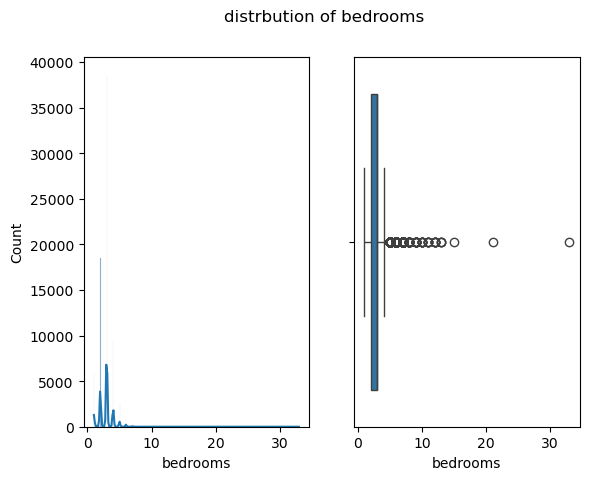

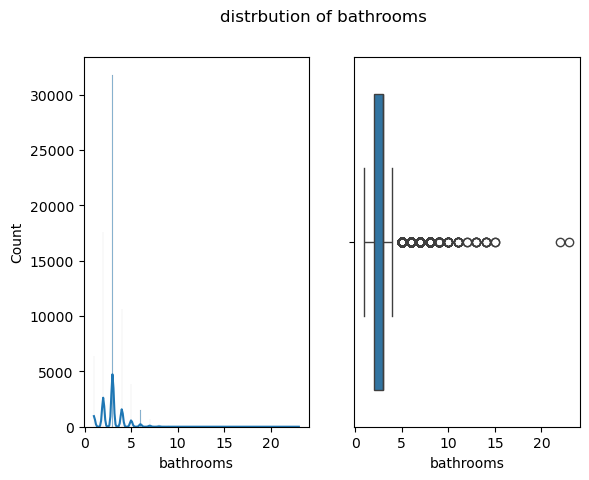

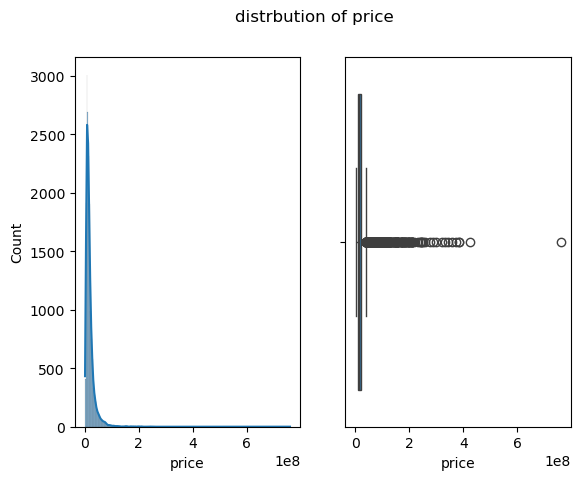

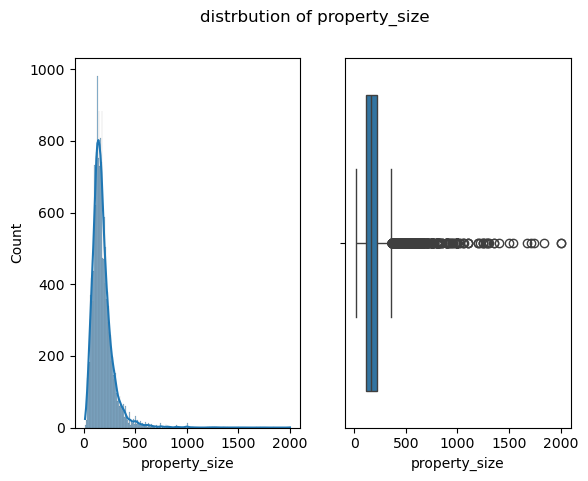

In [401]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# * Uni-variate

### NUMERIC
num_cols = df.select_dtypes('number').columns
for col in num_cols:
    fig, axes = plt.subplots(nrows=1, ncols=2)
    fig.suptitle(f'distrbution of {col}')
    ### histogram
    sns.histplot(df[col], kde=True, ax=axes[0])

    ### boxplot
    sns.boxplot(x=df[col], ax=axes[1])
    plt.show()

In [402]:
#### Categorical
# pie < 7
# countplot [7, 20]
# >20 top_10

cat_cols = df.select_dtypes("O").columns
cat_cols = cat_cols.drop(['url','logo_url', 'developer_url', 'property_title', 'reference_no'])

for col in cat_cols:
    if df[col].nunique() <= 7:
        fig = px.pie(df, names=df[col], title=f"Distribution of {col}")

    elif df[col].nunique() < 20:
        fig = px.histogram(df, x=col, title=f"Distribution of {col}")

    else: # top 10
        dff = df[col].value_counts().head(10).reset_index()
        dff.columns = [col, 'count']
        fig = px.bar(dff, x=col, y='count', title=f"Top 10 Distribution of {col}")
    
    fig.show()

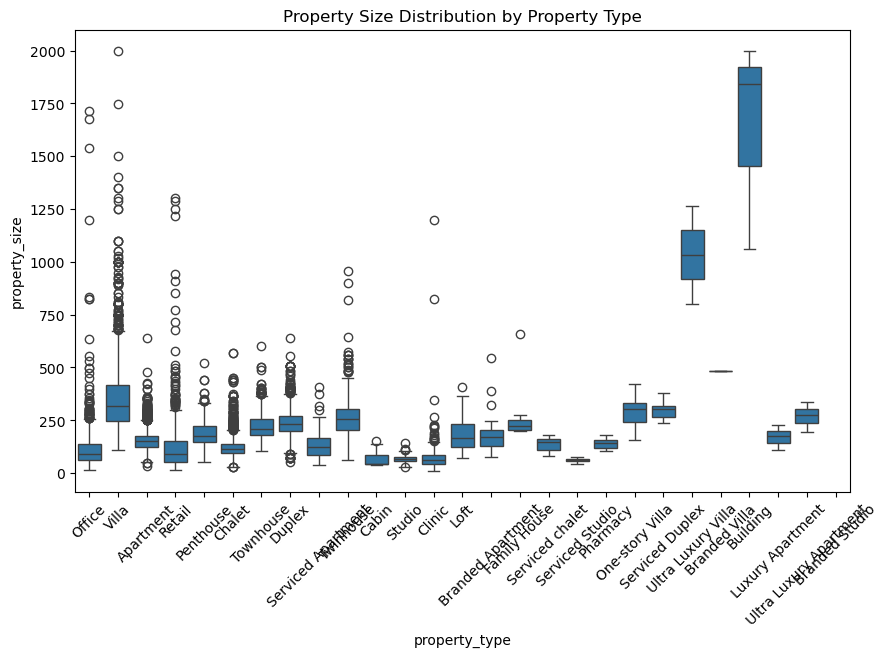

In [403]:
#### Bi-Variate Analysis
#1)Property Type vs Property Size
# x: property_type (categorical)
# y: property_size (numeric)

plt.figure(figsize=(10,6))
sns.boxplot(x="property_type", y="property_size", data=df)
plt.xticks(rotation=45)
plt.title("Property Size Distribution by Property Type")
plt.show()


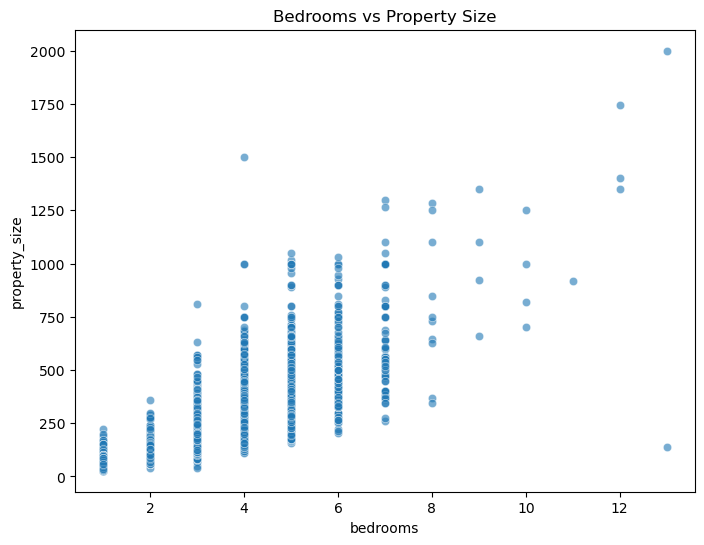

In [404]:
#2) Bedrooms vs Property Size
# x: bedrooms (numeric)
# y: property_size (numeric)

plt.figure(figsize=(8,6))
sns.scatterplot(x="bedrooms", y="property_size", data=df, alpha=0.6)
plt.title("Bedrooms vs Property Size")
plt.show()


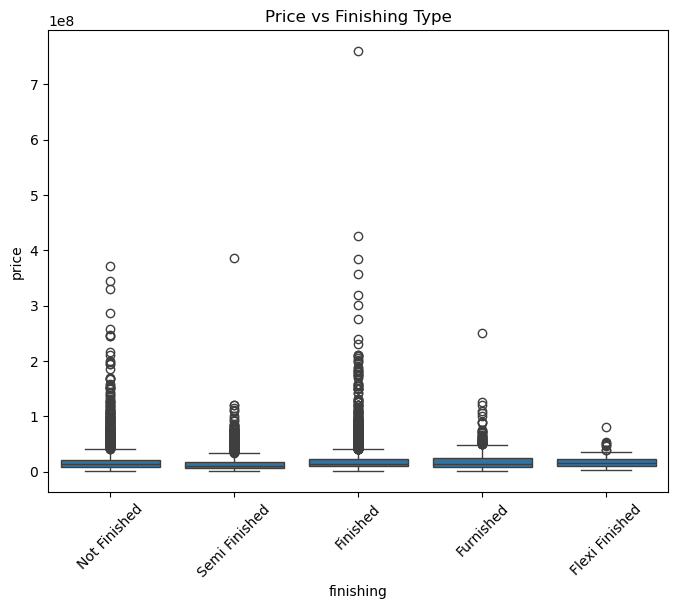

In [405]:
#3)Finishing Type vs Price
# x: finishing (categorical)
# y: price (numeric)

plt.figure(figsize=(8,6))
sns.boxplot(x="finishing", y="price", data=df)
plt.xticks(rotation=45)
plt.title("Price vs Finishing Type")
plt.show()


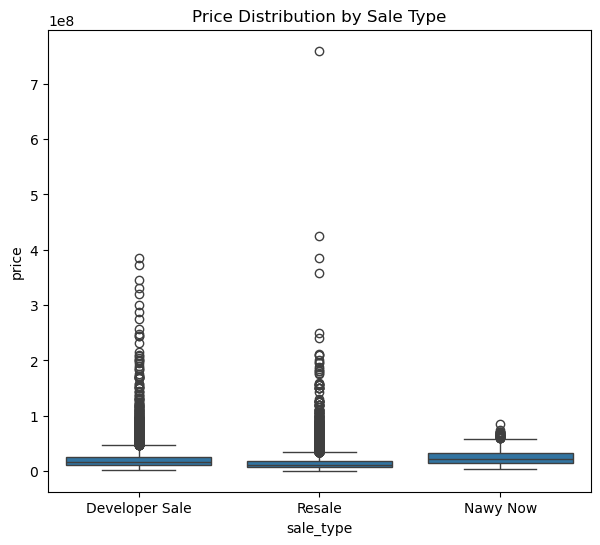

In [406]:
#4)Sale Type vs Price
# x: sale_type (categorical)
# y: price (numeric)

plt.figure(figsize=(7,6))
sns.boxplot(x="sale_type", y="price", data=df)
plt.title("Price Distribution by Sale Type")
plt.show()


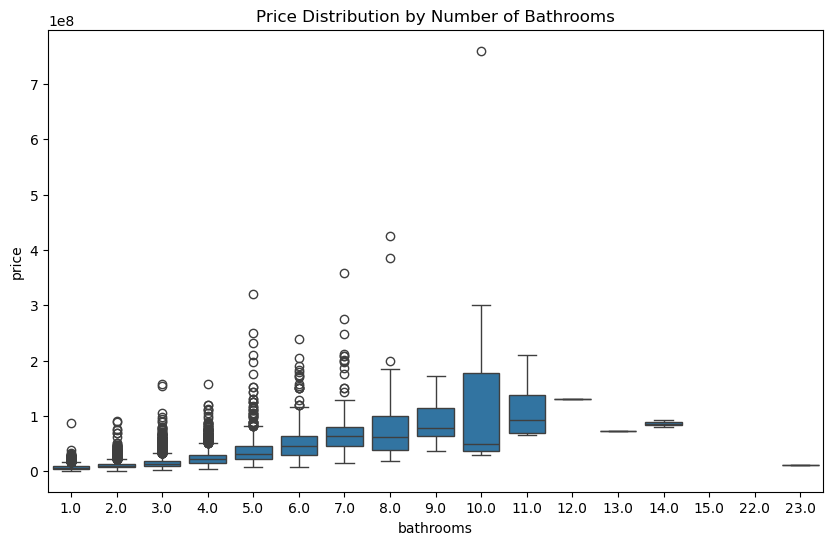

In [407]:
#5)Bathrooms vs Price
# x: bathrooms (numeric)
# y: price (numeric)

plt.figure(figsize=(10,6))
sns.boxplot(x="bathrooms", y="price", data=df)
plt.title("Price Distribution by Number of Bathrooms")
plt.show()


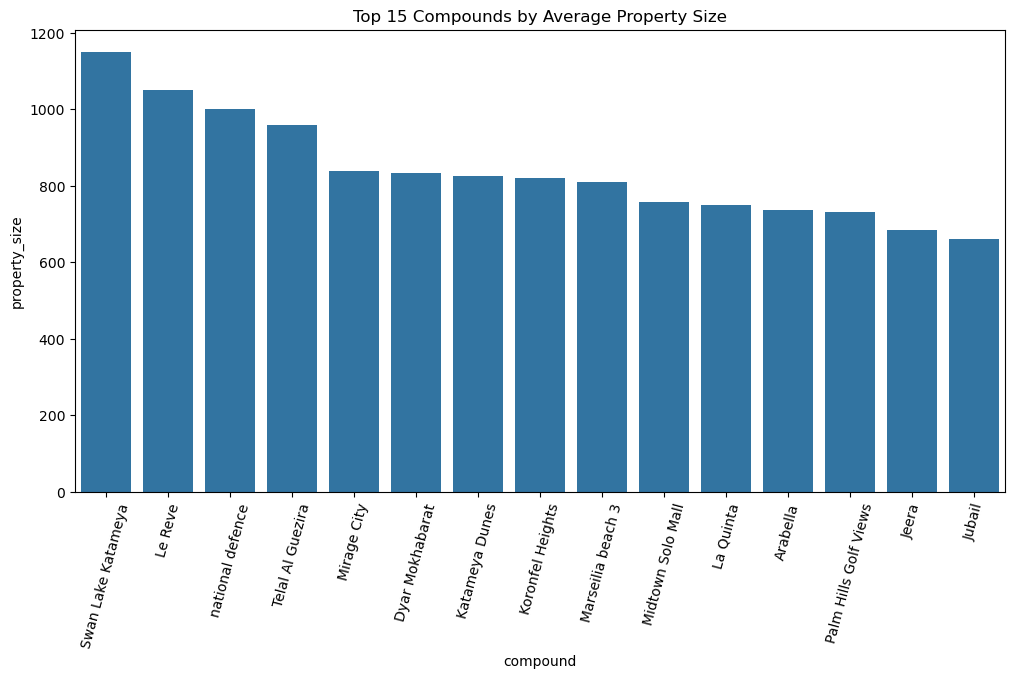

In [408]:
#6)Compound vs Average Property Size
# x: compound (categorical)
# y: average_property_size (numeric)

compound_size = df.groupby("compound")["property_size"].mean().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(x="compound", y="property_size", 
            data=compound_size.sort_values("property_size", ascending=False).head(15))
plt.xticks(rotation=75)
plt.title("Top 15 Compounds by Average Property Size")
plt.show()


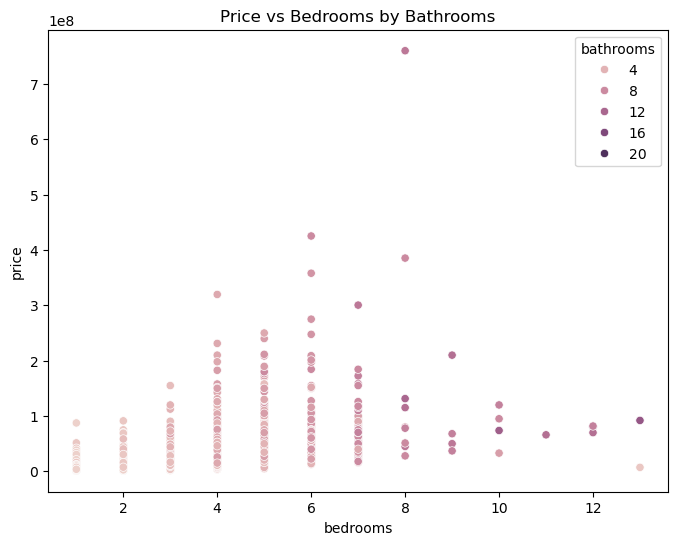

In [409]:
#7)How do bedrooms, bathrooms, and price relate?
# x: bedrooms (numeric)
# y: price (numeric)
# color: bathrooms (numeric)

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="bedrooms", y="price", hue="bathrooms")
plt.title("Price vs Bedrooms by Bathrooms")
plt.show()


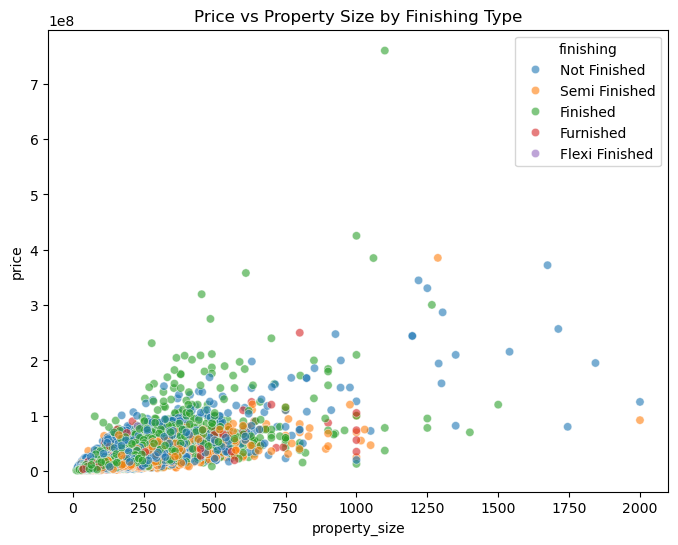

In [410]:
#8)How does finishing type affect the relationship between property size and price?
# x: property_size (numeric)
# y: price (numeric)
# color: finishing (categorical)

plt.figure(figsize=(8,6))
sns.scatterplot(x="property_size", y="price", hue="finishing", data=df, alpha=0.6)
plt.title("Price vs Property Size by Finishing Type")
plt.show()


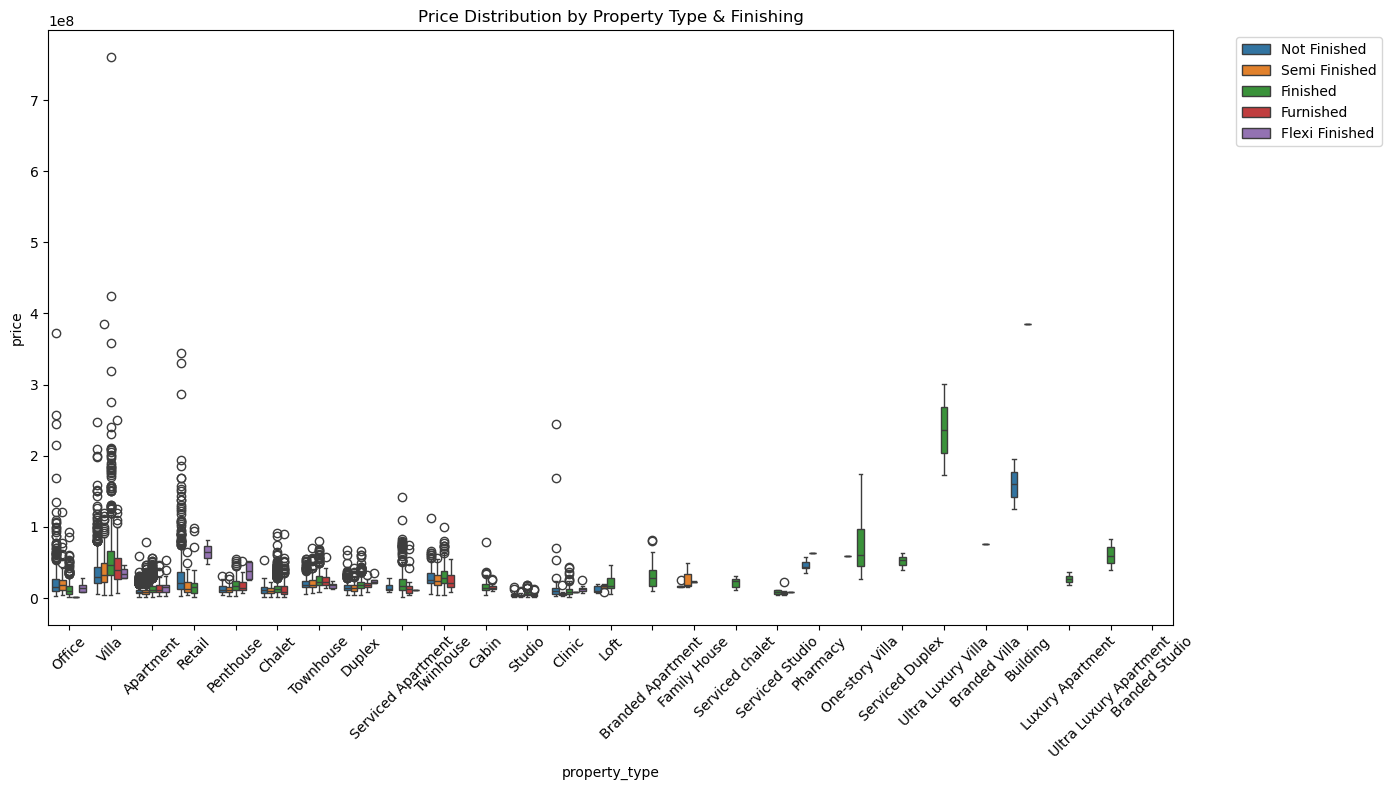

In [411]:
# 9) What is the relationship among property type, finishing type, and price?
# x: property_type (categorical)
# y: price (numeric)
# color: finishing (categorical)

plt.figure(figsize=(14,8))
sns.boxplot(x="property_type", y="price", hue="finishing", data=df)
plt.xticks(rotation=45)
plt.title("Price Distribution by Property Type & Finishing")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



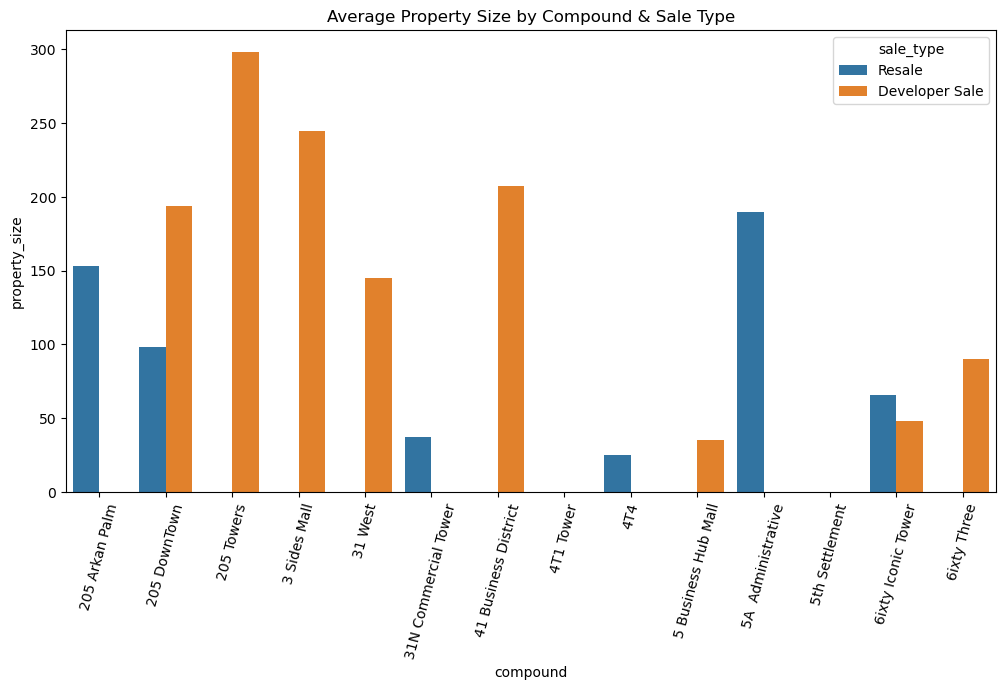

In [412]:
# 10) How do compound, sale type, and average property size interact?
# x: compound (categorical)
# y: average_property_size (numeric)
# color: sale_type (categorical)

compound_size = df.groupby(["compound", "sale_type"])["property_size"].mean().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(x="compound", y="property_size", hue="sale_type", data=compound_size.head(20))
plt.xticks(rotation=75)
plt.title("Average Property Size by Compound & Sale Type")
plt.show()


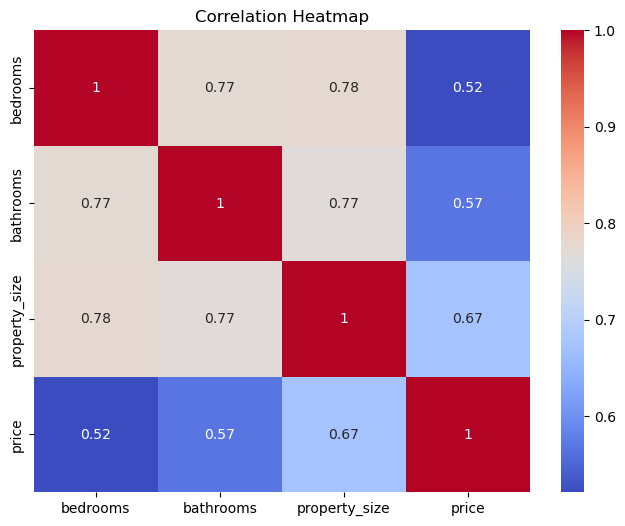

In [413]:
# 11) Which features (bedrooms, bathrooms, property size, and price) are most correlated?
# variables: bedrooms (numeric), bathrooms (numeric), property_size (numeric), price (numeric)

plt.figure(figsize=(8,6))
sns.heatmap(df[["bedrooms","bathrooms","property_size","price"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

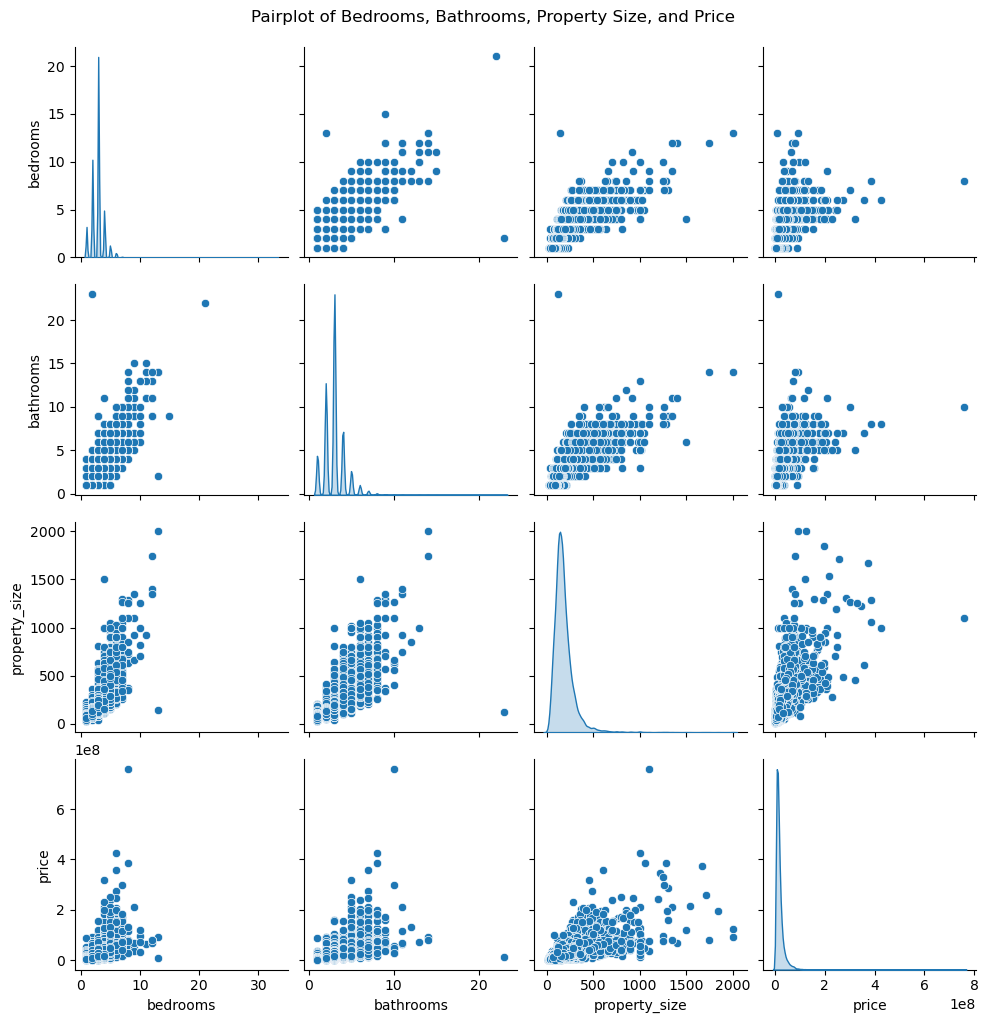

In [414]:
# 12) Which features (bedrooms, bathrooms, property size, price) are most related to each other? (pairplot)
# variables: bedrooms (numeric), bathrooms (numeric), property_size (numeric), price (numeric)

sns.pairplot(df[["bedrooms", "bathrooms", "property_size", "price"]], diag_kind="kde")
plt.suptitle("Pairplot of Bedrooms, Bathrooms, Property Size, and Price", y=1.02)
plt.show()


 #### 3) Pre-Processing Mind Map:
* A) Detect & Handle Duplicates
* B) train_test_split
* C) Detect & Handle NaNs
* D) Detect & Handle Outliers
* E) Encoding: (Ordinal:[OrdinalEncoder, LabelEncoder] - Nominal: [< 7 uniques(OneHotEncoding), > 7 uniques (BinaryEncoder)])
* F) Imbalanced: X_train_resampled
* G) Scaling: StandardScaler, MinMaxScaler, RobustScaler: X_train_resampled_scaled
* H)Feature Selection / Feature Engineering

In [ ]:
df

In [ ]:
#a) Detect & Handle Duplicates
df.duplicated().sum()

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
#b) train_test_split
from sklearn.model_selection import train_test_split

# Drop columns that are not useful as features (urls, text, reference_no, etc.)
X = df.drop([ 'url', 'logo_url', 'developer_url', 
              'property_title', 'amenities', 'reference_no','price'], axis=1)

# Target variable (what we want to predict)
y = df['price']

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Check dataset sizes
X_train.shape, X_test.shape, y_train.shape, y_test.shape


In [ ]:
#c) Detect & Handle NaNs
X_train.isna().sum()

In [ ]:
X_train.columns

In [ ]:
df.dtypes


In [ ]:
from sklearn.impute import SimpleImputer, KNNImputer



# Numeric columns → median
num_cols = ['bedrooms', 'bathrooms', 'price', 'property_size',]
median_imputer = SimpleImputer(strategy='median')
X_train[num_cols] = median_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = median_imputer.transform(X_test[num_cols])
y_train = y_train.fillna(y_train.median())
y_test = y_test.fillna(y_test.median())

# Categorical columns → most frequent
cat_cols = ['developer_name', 'property_type', 'location', 'compound', 'sale_type', 'finishing','delivery_in']
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])



In [ ]:
X_train['price'] = X_train['price'].astype(int)
X_test['price'] = X_test['price'].astype(int)

# bedrooms & bathrooms can safely remain float, but if you prefer int:
X_train[['bedrooms', 'bathrooms']] = X_train[['bedrooms', 'bathrooms']].astype(int)
X_test[['bedrooms', 'bathrooms']] = X_test[['bedrooms', 'bathrooms']].astype(int)

In [ ]:
X_train.isna().sum()

In [ ]:
#d) Detect & Handle Outliers
X_train

In [ ]:

X_train[['bedrooms', 'bathrooms', 'delivery_in', 'property_size']] = np.log1p(X_train[['bedrooms', 'bathrooms', 'delivery_in', 'property_size']])
X_test[['bedrooms', 'bathrooms', 'delivery_in', 'property_size']] = np.log1p(X_test[['bedrooms', 'bathrooms', 'delivery_in', 'property_size']])

sns.boxplot(X_train['property_size'])

In [ ]:
# Distribution plot
sns.histplot(X_train['property_size'], kde=True)

In [ ]:
#e) Encoding: (Ordinal:[OrdinalEncoder, LabelEncoder] - Nominal: [< 7 uniques(OneHotEncoding), > 7 uniques (BinaryEncoder)])
cat_cols = X_train.select_dtypes("O").columns
for col in cat_cols:
    print(col, X_train[col].nunique())

In [ ]:
cat_cols = X_train.select_dtypes("O").columns
from category_encoders import BinaryEncoder
bin_encoder = BinaryEncoder()
X_train_encoded = pd.concat([X_train, bin_encoder.fit_transform(X_train[cat_cols])], axis=1).drop(cat_cols, axis=1)
X_test_encoded = pd.concat([X_test, bin_encoder.transform(X_test[cat_cols])], axis=1).drop(cat_cols, axis=1)



In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler

# Standard scaling for normally distributed numerical columns
std_scaler = StandardScaler()
X_train_encoded[["bedrooms", "bathrooms", "delivery_in"]] = std_scaler.fit_transform(X_train_encoded[["bedrooms", "bathrooms", "delivery_in"]])
X_test_encoded[["bedrooms", "bathrooms", "delivery_in"]] = std_scaler.transform(X_test_encoded[["bedrooms", "bathrooms", "delivery_in"]])

# Robust scaling for columns that might have outliers
robust_scaler = RobustScaler()
X_train_encoded[["property_size"]] = robust_scaler.fit_transform(X_train_encoded[["property_size"]])
X_test_encoded[["property_size"]] = robust_scaler.transform(X_test_encoded[["property_size"]])

In [ ]:
X_train_encoded

In [ ]:
X_train_encoded.describe()

In [ ]:
imputer = SimpleImputer(strategy="median")
X_train_encoded = pd.DataFrame(imputer.fit_transform(X_train_encoded),
                               columns=X_train_encoded.columns)
X_test_encoded = pd.DataFrame(imputer.transform(X_test_encoded),
                              columns=X_test_encoded.columns)

In [ ]:
# X_train_encoded.to_csv("train_cleaned_encoded.csv", index=False)
# X_test_encoded.to_csv("test_cleaned_encoded.csv", index=False)

In [ ]:
#f) Imbalanced: X_train_resampled
# Skipped — Imbalance handling like RandomOverSampler 
# works only for classification (categorical y).
# Since 'price' is continuous, no resampling is applied.

In [ ]:
#g) Scaling: StandardScaler, MinMaxScaler, RobustScaler: X_train_resampled_scaled
from sklearn.preprocessing import StandardScaler, RobustScaler

# Standard scaling for normal-like columns
std_scaling_cols = ["bedrooms", "bathrooms", "delivery_in"]
std_scaler = StandardScaler()
X_train_encoded[std_scaling_cols] = std_scaler.fit_transform(X_train_encoded[std_scaling_cols])
X_test_encoded[std_scaling_cols] = std_scaler.transform(X_test_encoded[std_scaling_cols])

# Robust scaling for skewed columns (property_size)
robust_scaling_cols = ["property_size"]
robust_scaler = RobustScaler()
X_train_encoded[robust_scaling_cols] = robust_scaler.fit_transform(X_train_encoded[robust_scaling_cols])
X_test_encoded[robust_scaling_cols] = robust_scaler.transform(X_test_encoded[robust_scaling_cols])


In [ ]:
#h)Feature Selection / Feature Engineering
from sklearn.feature_selection import SelectKBest, f_regression

# Keep the top 15 features most correlated with target (price)
selector = SelectKBest(score_func=f_regression, k=15)
X_train_selected = selector.fit_transform(X_train_encoded, y_train)
X_test_selected = selector.transform(X_test_encoded)

# Get selected feature names
selected_features = X_train_encoded.columns[selector.get_support()]
print("Selected Features:", selected_features)


#### Streamlit


In [ ]:
df

In [ ]:
import streamlit as st
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Page configuration
st.set_page_config(
    page_title="Property Analysis Dashboard",
    page_icon="🏠",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Load and clean your property data
@st.cache_data
def load_and_clean_data():
    try:
        # Load the data
        df = pd.read_csv('property_data_08152025_v2.csv')
        
        # Data cleaning
        df_clean = df.copy()
        
        # Clean price column if it exists
        if 'price' in df_clean.columns:
            # Convert price to string first, then clean
            df_clean['price'] = df_clean['price'].astype(str)
            
            # Remove common non-numeric patterns
            df_clean['price'] = df_clean['price'].str.replace(',', '', regex=False)
            df_clean['price'] = df_clean['price'].str.replace('EGP', '', regex=False)
            df_clean['price'] = df_clean['price'].str.replace('$', '', regex=False)
            df_clean['price'] = df_clean['price'].str.replace('Call for price', '', regex=False)
            df_clean['price'] = df_clean['price'].str.replace('Negotiable', '', regex=False)
            df_clean['price'] = df_clean['price'].str.replace('N/A', '', regex=False)
            df_clean['price'] = df_clean['price'].str.replace('nan', '', regex=False)
            df_clean['price'] = df_clean['price'].str.strip()
            
            # Replace empty strings with NaN
            df_clean['price'] = df_clean['price'].replace('', np.nan)
            
            # Convert to numeric, errors='coerce' will convert invalid values to NaN
            df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce')
        
        # Clean property_size column if it exists
        if 'property_size' in df_clean.columns:
            df_clean['property_size'] = df_clean['property_size'].astype(str)
            df_clean['property_size'] = df_clean['property_size'].str.replace('sqm', '', regex=False)
            df_clean['property_size'] = df_clean['property_size'].str.replace('m²', '', regex=False)
            df_clean['property_size'] = df_clean['property_size'].str.replace(',', '', regex=False)
            df_clean['property_size'] = df_clean['property_size'].str.strip()
            df_clean['property_size'] = df_clean['property_size'].replace('', np.nan)
            df_clean['property_size'] = pd.to_numeric(df_clean['property_size'], errors='coerce')
        
        # Clean other numeric columns
        numeric_columns = ['bedrooms', 'bathrooms', 'floors']
        for col in numeric_columns:
            if col in df_clean.columns:
                df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        
        return df_clean
        
    except FileNotFoundError:
        st.error("⚠️ Data file not found! Please make sure 'property_data_08152025_v2.csv' is in the same folder.")
        return None
    except Exception as e:
        st.error(f"Error loading data: {e}")
        return None

# Load data
df = load_and_clean_data()

# Only proceed if data is loaded successfully
if df is not None:
    # Sidebar navigation
    st.sidebar.title("🏠 Property Analysis App")
    page_option = st.sidebar.radio(
        label='Navigate to:', 
        options=['Data Explorer', 'Interactive Plots']
    )

    def data_page():
        st.title("🏠 Property Data Explorer")
        st.write("### Overview of Egyptian Property Market Data")
        
        # Show basic info with error handling
        col1, col2, col3, col4 = st.columns(4)
        
        with col1:
            st.metric("Total Properties", f"{len(df):,}")
        
        with col2:
            if 'property_type' in df.columns:
                st.metric("Property Types", df['property_type'].nunique())
            else:
                st.metric("Property Types", "N/A")
        
        with col3:
            if 'price' in df.columns:
                # Use only valid (non-NaN) prices for calculation
                valid_prices = df['price'].dropna()
                if len(valid_prices) > 0:
                    avg_price = valid_prices.mean()
                    st.metric("Average Price", f"{avg_price:,.0f} EGP")
                    st.caption(f"Based on {len(valid_prices):,} valid prices")
                else:
                    st.metric("Average Price", "N/A")
                    st.caption("No valid price data found")
            else:
                st.metric("Average Price", "N/A")
        
        with col4:
            if 'property_size' in df.columns:
                # Use only valid (non-NaN) sizes for calculation
                valid_sizes = df['property_size'].dropna()
                if len(valid_sizes) > 0:
                    avg_size = valid_sizes.mean()
                    st.metric("Average Size", f"{avg_size:.0f} sqm")
                    st.caption(f"Based on {len(valid_sizes):,} valid sizes")
                else:
                    st.metric("Average Size", "N/A")
                    st.caption("No valid size data found")
            else:
                st.metric("Average Size", "N/A")
        
        # Show data quality info
        st.write("### Data Quality Overview")
        if 'price' in df.columns:
            total_rows = len(df)
            valid_prices = df['price'].notna().sum()
            invalid_prices = total_rows - valid_prices
            
            col1, col2, col3 = st.columns(3)
            with col1:
                st.metric("Total Rows", f"{total_rows:,}")
            with col2:
                st.metric("Valid Prices", f"{valid_prices:,}")
            with col3:
                st.metric("Missing/Invalid Prices", f"{invalid_prices:,}")
        
        # Show dataset overview
        st.write("### Dataset Overview")
        st.write(f"**Rows:** {df.shape[0]:,} | **Columns:** {df.shape[1]}")
        
        # Show column info with data types
        st.write("### Available Columns")
        col_info = pd.DataFrame({
            'Column': df.columns,
            'Data Type': df.dtypes,
            'Non-Null Count': df.count(),
            'Null Count': df.isnull().sum()
        })
        st.dataframe(col_info)
        
        # Show sample data
        st.write("### Sample Data")
        st.dataframe(df.head())
        
        # Property type distribution
        if 'property_type' in df.columns:
            st.write("### Property Type Distribution")
            prop_counts = df['property_type'].value_counts()
            
            col1, col2 = st.columns(2)
            with col1:
                st.dataframe(prop_counts.head(10))
            with col2:
                fig = px.pie(values=prop_counts.values, names=prop_counts.index, 
                           title="Property Types Distribution")
                st.plotly_chart(fig, use_container_width=True)
        
        # Filter options
        if 'property_type' in df.columns:
            st.write("### Filter and Explore")
            property_types = st.multiselect(
                "Filter by Property Type:",
                options=df['property_type'].unique(),
                default=df['property_type'].unique()[:min(3, len(df['property_type'].unique()))]
            )
            
            if property_types:  # Only filter if something is selected
                # Apply filters
                filtered_df = df[df['property_type'].isin(property_types)]
                
                # Show filtered data
                display_columns = []
                for col in ['property_type', 'location', 'bedrooms', 'bathrooms', 'price', 'property_size', 'finishing']:
                    if col in df.columns:
                        display_columns.append(col)
                
                if display_columns:
                    st.dataframe(filtered_df[display_columns])
                
                # Summary statistics for numeric columns
                numeric_cols = filtered_df.select_dtypes(include=[np.number]).columns
                if len(numeric_cols) > 0:
                    st.write("### Summary Statistics")
                    st.dataframe(filtered_df[numeric_cols].describe())

    def plots_page():
        st.title("📊 Interactive Property Analysis")
        
        # Check available columns
        available_cols = df.columns.tolist()
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
        
        # Plot selection
        plot_type = st.selectbox(
            "Choose Analysis Type:",
            ['Price Distribution', 'Property Comparison', 'Location Analysis']
        )
        
        if plot_type == 'Price Distribution':
            st.subheader("💰 Price Analysis")
            
            if 'price' not in df.columns:
                st.error("Price column not found in the dataset!")
                return
            
            # Check if we have valid price data
            valid_price_data = df['price'].dropna()
            if len(valid_price_data) == 0:
                st.error("No valid price data found in the dataset!")
                return
            
            # X-axis selection from categorical columns
            cat_options = [col for col in ['property_type', 'finishing', 'sale_type', 'compound'] 
                          if col in categorical_cols]
            
            if cat_options:
                x_option = st.selectbox(
                    'Select Category for Analysis:', 
                    options=cat_options, 
                    index=0
                )
                
                if st.button("Show Price Distribution"):
                    # Filter out rows with missing prices
                    plot_df = df.dropna(subset=['price'])
                    
                    if len(plot_df) > 0:
                        # Create box plot
                        fig = px.box(plot_df, x=x_option, y='price', 
                                    title=f'Price Distribution by {x_option.replace("_", " ").title()}')
                        st.plotly_chart(fig, use_container_width=True)
                        
                        # Show summary stats
                        st.write(f"### Price Summary by {x_option.replace('_', ' ').title()}")
                        summary = plot_df.groupby(x_option)['price'].agg(['mean', 'median', 'count']).round(2)
                        st.dataframe(summary)
                    else:
                        st.error("No valid data available for plotting after removing missing prices.")
            else:
                st.warning("No suitable categorical columns found for price analysis.")
        
        elif plot_type == 'Property Comparison':
            st.subheader("🏠 Property Features Analysis")
            
            if 'price' not in df.columns:
                st.error("Price column not found in the dataset!")
                return
            
            # Check if we have valid price data
            valid_price_data = df['price'].dropna()
            if len(valid_price_data) == 0:
                st.error("No valid price data found in the dataset!")
                return
            
            # Multi-variable analysis
            numeric_options = [col for col in ['bedrooms', 'bathrooms', 'property_size'] 
                              if col in numeric_cols]
            color_options = [col for col in ['property_type', 'finishing', 'sale_type'] 
                            if col in categorical_cols]
            
            if numeric_options and color_options:
                x_var = st.selectbox('X-axis:', numeric_options)
                color_var = st.selectbox('Color by:', color_options)
                
                if st.button("Show Comparison"):
                    # Filter out rows with missing data
                    plot_df = df.dropna(subset=['price', x_var])
                    
                    if len(plot_df) > 0:
                        hover_cols = [col for col in ['location', 'compound'] if col in df.columns]
                        fig = px.scatter(plot_df, x=x_var, y='price', color=color_var,
                                       title=f'Price vs {x_var.title()} (Colored by {color_var.replace("_", " ").title()})',
                                       hover_data=hover_cols)
                        st.plotly_chart(fig, use_container_width=True)
                    else:
                        st.error("No valid data available for plotting after removing missing values.")
            else:
                st.warning("Insufficient columns for property comparison.")
        
        elif plot_type == 'Location Analysis':
            st.subheader("📍 Location-Based Analysis")
            
            if 'location' not in df.columns:
                st.error("Location column not found in the dataset!")
                return
            
            # Extract city from location
            df_temp = df.copy()
            df_temp['city'] = df_temp['location'].str.split(',').str[1].str.strip()
            
            # Top cities by property count
            top_cities = df_temp['city'].value_counts().head(10)
            
            col1, col2 = st.columns(2)
            
            with col1:
                st.write("### Top Cities by Property Count")
                fig1 = px.bar(x=top_cities.index, y=top_cities.values,
                             title='Properties per City')
                st.plotly_chart(fig1, use_container_width=True)
            
            with col2:
                if 'price' in df.columns:
                    # Filter for valid prices before calculating city averages
                    df_temp_valid = df_temp.dropna(subset=['price'])
                    if len(df_temp_valid) > 0:
                        st.write("### Average Price by City")
                        city_prices = df_temp_valid.groupby('city')['price'].mean().sort_values(ascending=False).head(10)
                        fig2 = px.bar(x=city_prices.index, y=city_prices.values,
                                     title='Average Price per City')
                        st.plotly_chart(fig2, use_container_width=True)
                    else:
                        st.write("No valid price data available for city analysis.")
                else:
                    st.write("Price column not available for city analysis.")

    # Page routing
    if page_option == 'Data Explorer':
        data_page()
    elif page_option == 'Interactive Plots':
        plots_page()

    # Footer
    st.sidebar.markdown("---")
    st.sidebar.markdown("Built with ❤️ using Streamlit")
    st.sidebar.markdown("Property Data Analysis Dashboard")

else:
    st.title("❌ Data Loading Error")
    st.write("Please check:")
    st.write("1. Make sure your CSV file exists")
    st.write("2. Check the file path and name")
    st.write("3. Ensure the file is not corrupted")

In [ ]:
import numpy as pkg
pkg.__version__